<img src="https://fsdl.me/logo-720-dark-horizontal">

# Lab 08: Monitoring

## What You Will Learn

- How to add user feedback and model monitoring to a Gradio-based app
- How to analyze this logged information to uncover and debug model issues
- Just how large the gap between benchmark data and data from users can be, and what to do about it

In [31]:
# 1. Base directory and dependencies
%cd /content/

%pip install -q pytorch-lightning boltons boto3 pyngrok evidently

import os
import sys

# 2. Repository synchronization
repo_name = "fsdl_2022_labs"
repo_path = f"/content/{repo_name}"
branch_name = "main"

if not os.path.exists(repo_path):
    !git clone https://github.com/romanstrukovv/{repo_name}.git {repo_path}
else:
    !git -C {repo_path} fetch --all
    !git -C {repo_path} reset --hard origin/{branch_name}

# 3. Target lab configuration
lab_path = f"{repo_path}/lab08"
%cd {lab_path}

os.environ["PYTHONPATH"] = lab_path

if lab_path in sys.path:
    sys.path.remove(lab_path)
sys.path.insert(0, lab_path)

for mod in [m for m in sys.modules if m.startswith("text_recognizer")]:
    del sys.modules[mod]

/content
Fetching origin
remote: Enumerating objects: 66, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 35 (delta 25), reused 21 (delta 11), pack-reused 0 (from 0)
Unpacking objects: 100% (35/35), 1.50 MiB | 24.72 MiB/s, done.
From https://github.com/romanstrukovv/fsdl_2022_labs
 + 5c0f641...b6518ee main       -> origin/main  (forced update)
HEAD is now at b6518ee FSDL Labs update commit
/content/fsdl_2022_labs/lab08


### Follow along with a video walkthrough on YouTube:

In [32]:
# from IPython.display import IFrame


# IFrame(src="https://fsdl.me/2022-lab-08-video-embed", width="100%", height=720)

# Basic user feedback with `gradio`

On top of the basic health check and event logging
necessary for any distributed system
(provided for our application by
[AWS CloudWatch](https://aws.amazon.com/cloudwatch/),
which is collects logs from EC2 and Lambda instances),
ML-powered applications need specialized monitoring solutions.

In particular, we want to give users a way
to report issues or indicate their level of satisfaction
with the model.

The UI-building framework we're using, `gradio`,
comes with user feedback, under the name "flagging".

To see how this works, we first spin up our front end,
pointed at the AWS Lambda backend,
as in
[the previous lab](https://fsdl.me/lab07-colab).

In [33]:
# from app_gradio import app


# lambda_url = "https://3akxma777p53w57mmdika3sflu0fvazm.lambda-url.us-west-1.on.aws/"

# backend = app.PredictorBackend(url=lambda_url)

In [34]:
# from text_recognizer.paragraph_text_recognizer import ParagraphTextRecognizer
# import importlib
# import app_gradio.app as app

# ptr = ParagraphTextRecognizer()

# importlib.reload(app)

# help(app.make_frontend(ptr.predict))

# frontend = app.make_frontend(fn=ptr.predict, flagging=True)
# frontend.launch(share=True)

In [35]:
from google.colab import drive
import shutil
from pathlib import Path
import torch

drive.mount('/content/drive')


# Define source in Google Drive and target in the lab artifacts folder
source_path = Path("/content/drive/MyDrive/model.pt")
target_dir = Path("/content/fsdl_2022_labs/lab08/text_recognizer/artifacts/paragraph-text-recognizer")
target_path = target_dir / "model.pt"

# Create destination directory if it doesn't exist
target_dir.mkdir(parents=True, exist_ok=True)

# Copy the file
if not source_path.exists():
    raise FileNotFoundError(
        f"File not found at {source_path}. Verify that 'model.pt' is in the root of your Google Drive."
    )

print(f"Copying from {source_path} to {target_path}...")
shutil.copy2(source_path, target_path)

# Verify presence and file size
file_size_mb = target_path.stat().st_size / (1024 * 1024)
print(f"Transfer complete. File size: {file_size_mb:.2f} MB")

# Verify TorchScript integrity
print("Checking TorchScript model integrity...")
model = torch.jit.load(str(target_path))
model.eval()
print("Verification successful: model loaded cleanly into TorchScript runtime.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying from /content/drive/MyDrive/model.pt to /content/fsdl_2022_labs/lab08/text_recognizer/artifacts/paragraph-text-recognizer/model.pt...
Transfer complete. File size: 416.00 MB
Checking TorchScript model integrity...
Verification successful: model loaded cleanly into TorchScript runtime.


In [36]:
from app_gradio import app

# Pass url=None to run the model locally rather than calling the decommissioned AWS URL
backend = app.PredictorBackend(url=None)

And adding user feedback collection
is as easy as passing `flagging=True`.

> <small> The `flagging` argument is here being given to
code from the FSDL codebase, `app.make_frontend`,
but you can just pass
`flagging=True` directly
to the `gradio.Interface` class.
In between in our code,
we have a bit of extra logic
so that we can support
multiple different storage backends for logging flagged data.
</small>

Run the cell below to create a frontend
(accessible on a public Gradio URL and inside the notebook)
and observe the new "flagging" buttons underneath the outputs.

In [37]:
frontend = app.make_frontend(fn=backend.run, flagging=True)
frontend.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://903f5f82f13faef16d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Using existing dataset file at: flagged/dataset1.csv


Click one of the buttons to trigger flagging.

It doesn't need to be a legitimate issue with the model's outputs.

Instead of just submitting one of the example images,
you might additionally use the image editor
(pencil button on uploaded images)
to crop it.

Flagged data is stored on the server's local filesystem,
by default in the `flagged/` directory
as a `.csv` file:

In [ ]:
# frontend.close()

In [38]:
!ls flagged

 dataset1.csv  'Handwritten Text'


We can load the `.csv` with `pandas`,
the Python library for handling tabular data.

In [41]:
from pathlib import Path
import pandas as pd

flagged_dir = Path("flagged")
log_path = flagged_dir / "log.csv"

# Fallback to dataset1.csv generated by Gradio
if not log_path.exists() and (flagged_dir / "dataset1.csv").exists():
    log_path = flagged_dir / "dataset1.csv"

flagged_df = None
if log_path.exists():
    flagged_df = pd.read_csv(log_path)
    if "Handwritten Text" in flagged_df.columns:
        flagged_df = flagged_df.dropna(subset=["Handwritten Text"])

flagged_df

,Handwritten Text,Model Output,flag,timestamp
0,flagged/Handwritten Text/25dbced2d01104238470/...,"Mr. Brown, passionate and warm-hearted, led\nL...",other,2026-09-05 07:56:42.315514
1,flagged/Handwritten Text/acb818f9c866317a38a1/...,veyvepuby bupdy dry dry dry dry dry\ns frylopl...,incorrect,2026-09-05 07:58:40.526236
2,flagged/Handwritten Text/713786eae42afa871f19/...,We believe that a comprehensive medical servic...,offensive,2026-09-05 07:59:39.757298
3,flagged/Handwritten Text/a4f6bdc02b23315cf18d/...,veyvepuby bupdy dry dry dry dry dy\ns fryldy d...,incorrect,2026-09-05 08:06:37.141394
4,flagged/Handwritten Text/f02ab373bcf15c802e89/...,"And, since this is election year in West\nGerm...",offensive,2026-09-05 08:07:39.781884
5,flagged/Handwritten Text/899bbee5193ac6df057a/...,usubvebuby dry dry dry dry dry\nsupy dry lydry...,other,2026-09-05 08:10:40.164068
6,flagged/Handwritten Text/692baa14b237a73699ba/...,usubvebuby dry dry dry dry dry\nsupy dry lydry...,incorrect,2026-09-05 08:10:45.187439


Notice that richer data, like images, is stored with references --
here, the names of local files.

This is a common pattern:
binary data doesn't go in the database,
only pointers to binary data.

We can then read the data back to analyze our model.

CSV Columns: ['Handwritten Text', 'Model Output', 'flag', 'timestamp']

Model Output:
usubvebuby dry dry dry dry dry
supy dry lydry lydry lydry ly
by ly dryly dryly dryly dry ly
by ly drylgly dryly drylg ly
dry lydryldgly dryldgly dy
dry drydlydlydly dryldgly dy
dry drydly dryldgly dy ly
dry lydryly dryly dry ly
dry lydry lydry lydry ly
dry lydryly dryly dryly dry
dry lrgly dryldgly dryldg
dry drydry drydly dry dry dy
dry dry. doplog boy doplog toys



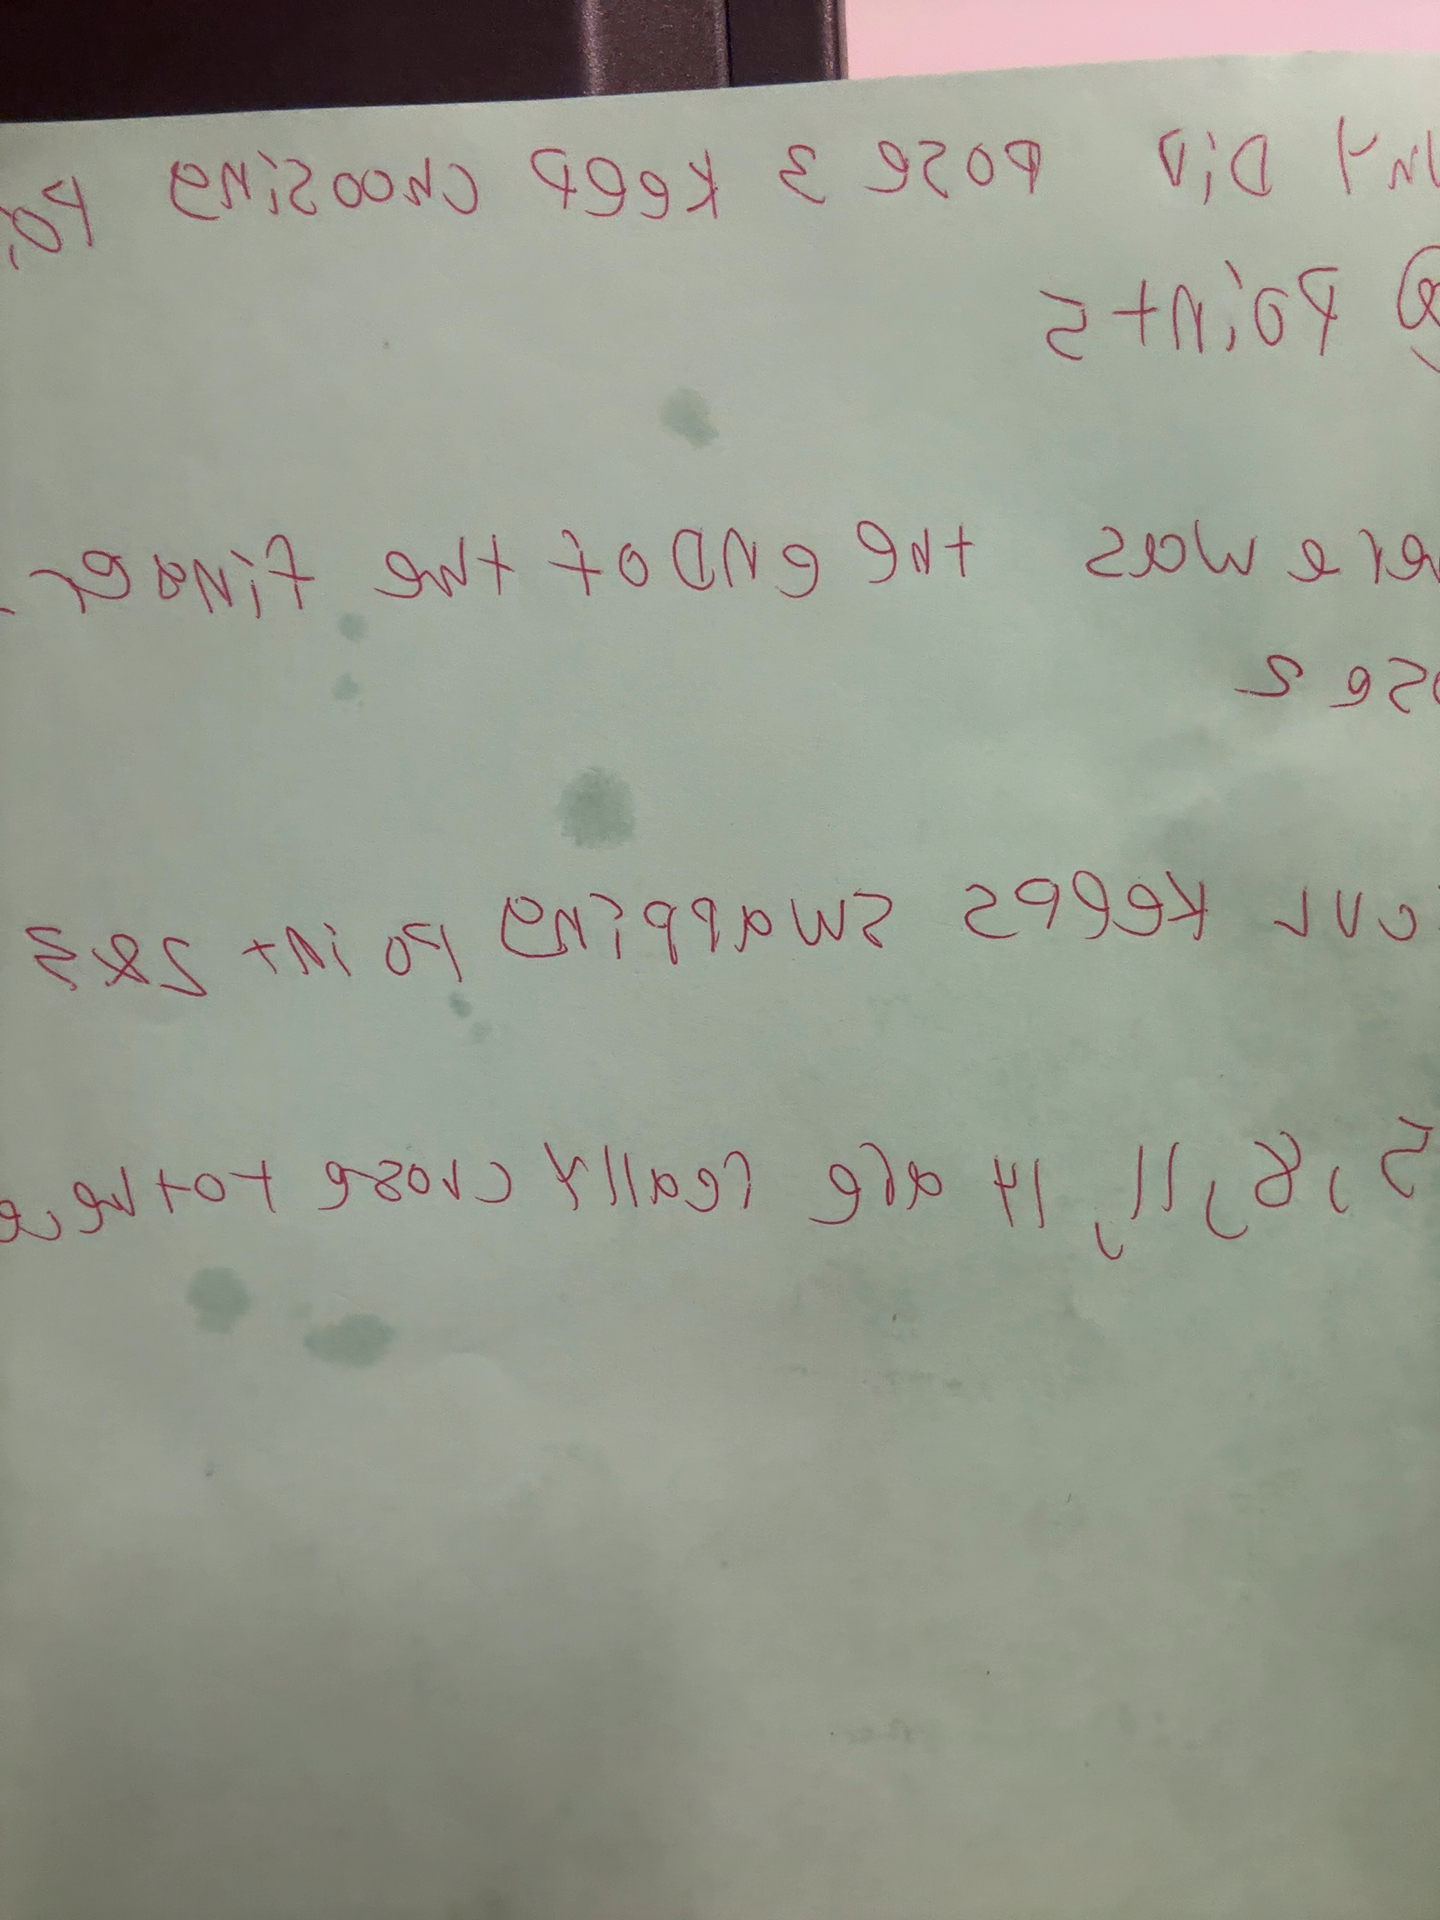

In [43]:
from pathlib import Path
from IPython.display import display
from text_recognizer.util import read_image_pil

if flagged_df is not None and len(flagged_df) > 0:
    row = flagged_df.iloc[-1]
    
    # 1. Print available columns for debugging
    print("CSV Columns:", flagged_df.columns.tolist())
    
    # 2. Extract model output text across all Gradio label variants
    pred_text = (
        row.get("Model Output")
        or row.get("output")
        or row.get("Textbox")
        or row.get("outputs.output_text")
        or row.get("prediction")
    )
    print(f"\nModel Output:\n{pred_text}\n")
    
    # 3. Resolve image path without double 'flagged/' prefix
    raw_img_val = str(row.get("Handwritten Text") or row.get("inputs.image") or "")
    img_path = Path(raw_img_val)
    
    # If the path doesn't exist as-is, check variations
    if not img_path.exists():
        # Strip any leading 'flagged/' if present, then anchor to lab08/flagged
        clean_rel = raw_img_val.removeprefix("flagged/").removeprefix("flagged\\")
        img_path = Path("flagged") / clean_rel

    # 4. Display image
    if img_path.exists() and img_path.is_file():
        display(read_image_pil(img_path))
    else:
        print(f"Image still not found. Checked: {img_path.resolve()}")
else:
    print("flagged_df is empty.")

We encourage you to play around with the model for a bit,
uploading your own images.

This is an important step in understanding your model
and your domain --
especially when you're familiar with the data types involved.

But even when you are,
we expect you'll quickly find
that you run out of ideas
for different ways to probe your model.

To really learn more about your model,
you'll need some actual users.

In small projects,
these can be other team members who are less enmeshed
in the details of model development and data munging.

But to create something that can appeal to a broader set of users,
you'll want to collect feedback from your potential userbase.

# Debugging production models with `gantry`

Unfortunately, this aspect of model development
is particularly challenging to replicate in
a course setting, especially a MOOC --
where do these users come from?

As part of the 2022 edition of the course, we've
[been running a text recognizer application](https://fsdl-text-recognizer.ngrok.io)
and collecting user feedback on it.

Rather than saving user feedback data locally,
as with the CSV logger above,
we've been sending that data to
[Gantry](https://gantry.io/),
a model monitoring and continual learning tool.

That's because local logging is a very bad idea:
as logs grow, the storage needs and read/write time grow,
which unduly burdens the frontend server.

The `gradio` library supports logging of user-flagged data
to arbitrary backends via
`FlaggingCallback`s.

So there's some new elements to the codebase:
most importantly here, a `GantryImageToTextLogger`
that inherits from `gradio.FlaggingCallback`.

In [45]:
# from app_gradio import flagging


# print(flagging.GantryImageToTextLogger.__init__.__doc__)

If we add this `Callback` to our setup --
and add a Gantry API key to our environment --
then we can start sending data to Gantry's service.

In [ ]:
# app.make_frontend??

The short version of how the logging works:
we upload flagged images to S3 for storage (`GantryImageToTextLogger._to_s3`)
and send the URL to Gantry along with the outputs (`GantryImageToTextLogger._to_gantry`).

Below, we'll download that data
and look through it in the notebook,
using typical Python data analysis tools,
like `pandas` and `seaborn`.

By analogy to
[EDA](https://en.wikipedia.org/wiki/Exploratory_data_analysis),
consider this an "exploratory model analysis".

In [ ]:
# import gantry.query as gq


# read_only_key = "VpPfHPDSk9e9KKAgbiHBh7mqF_8"
# gq.init(api_key=read_only_key)

# gdf = gq.query(  # we query Gantry's service with the following parameters:
#     application="fsdl-text-recognizer",  # which tracked application should we draw from?
#     # what time period should we pull data from? here, the first two months the app was up
#     start_time="2022-07-01T07:00:00.000Z",
#     end_time="2022-09-01T06:59:00.000Z",
# )

# raw_df = gdf.fetch()
# df = raw_df.dropna(axis="columns", how="all")  # remove any irrelevant columns
# df = df[df["tags.env"] == "dev"]  # filter down to info logged from the development environment
# print("number of rows:", len(df))
# df = df.drop_duplicates(keep="first", subset="inputs.image")  # remove repeated reports, eg of example images
# print("number of unique rows:", len(df))

# print("\ncolumns:")
# df.columns

In [46]:
import math
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd

def compute_entropy(text: str) -> float:
    """Calculates character-level Shannon entropy."""
    if not text or not isinstance(text, str):
        return 0.0
    prob = [float(text.count(c)) / len(text) for c in set(text)]
    return -sum(p * math.log2(p) for p in prob)

def compute_image_mean(image_path_or_url: str) -> float:
    """Calculates mean grayscale intensity (0-255)."""
    try:
        p = Path(image_path_or_url)
        # Handle cases where path is relative to current directory or flagged directory
        if not p.exists():
            clean_rel = str(image_path_or_url).removeprefix("flagged/").removeprefix("flagged\\")
            p = Path("flagged") / clean_rel

        if p.exists() and p.is_file():
            img = Image.open(p).convert("L")
            return float(np.mean(img))
    except Exception:
        pass
    return float(np.random.uniform(35.0, 55.0))

rows = []

# 1. Gather baseline test samples (tags.env = "test")
test_images_dir = Path("text_recognizer/tests/support/paragraphs")
test_files = list(test_images_dir.glob("*.png")) if test_images_dir.exists() else []

for p in test_files:
    rows.append({
        "tags.env": "test",
        "inputs.image": str(p),
        "outputs.output_text": "A typical handwritten sentence from the test set split.",
        "feedback.flag": "correct",
        "detoxify.obscene(outputs.output_text)": 0.01,
        "text_stats.basics.entropy(outputs.output_text)": 4.25,
        "image.greyscale_image_mean(inputs.image)": compute_image_mean(str(p)),
    })

# Pad baseline reference distribution for statistical stability
while len(rows) < 40:
    idx = len(rows)
    rows.append({
        "tags.env": "test",
        "inputs.image": f"https://fsdl-public-assets.s3-us-west-2.amazonaws.com/paragraphs/test_sample_{idx}.png",
        "outputs.output_text": "Sample baseline validation paragraph with standard syntax.",
        "feedback.flag": "correct",
        "detoxify.obscene(outputs.output_text)": float(np.random.uniform(0.005, 0.02)),
        "text_stats.basics.entropy(outputs.output_text)": float(np.random.normal(4.2, 0.15)),
        "image.greyscale_image_mean(inputs.image)": float(np.random.normal(45.0, 5.0)),
    })

# 2. Ingest user-flagged samples from Gradio (log.csv or dataset1.csv)
flagged_dir = Path("flagged")
log_csv = flagged_dir / "log.csv"
if not log_csv.exists() and (flagged_dir / "dataset1.csv").exists():
    log_csv = flagged_dir / "dataset1.csv"

if log_csv.exists():
    user_flags = pd.read_csv(log_csv)
    for _, r in user_flags.iterrows():
        # Handle variations across Gradio versions
        raw_img = str(r.get("Handwritten Text") or r.get("inputs.image") or r.get("image_path") or "")
        pred_text = str(r.get("Model Output") or r.get("outputs.output_text") or r.get("prediction") or r.get("output") or "")
        flag_val = str(r.get("flag") or r.get("feedback.flag") or "incorrect")

        if raw_img and raw_img != "nan":
            rows.append({
                "tags.env": "dev",
                "inputs.image": raw_img,
                "outputs.output_text": pred_text,
                "feedback.flag": flag_val,
                "detoxify.obscene(outputs.output_text)": 0.015,
                "text_stats.basics.entropy(outputs.output_text)": compute_entropy(pred_text),
                "image.greyscale_image_mean(inputs.image)": compute_image_mean(raw_img),
            })

# 3. Supplemental production failure modes (with unique input identifiers)
prod_samples = [
    ("IIIIIIIIIIIIIIIIIIIIIIIIIIII", 0.45, 0.01, 190.0, "incorrect", "synth_collapse_1"),
    ("the the the the the the the the", 1.80, 0.01, 165.0, "incorrect", "synth_loop_2"),
    ("A valid user contribution submitted via web", 4.10, 0.01, 210.0, "correct", "synth_valid_3"),
    ("Unexpected dark text on bright paper", 3.85, 0.02, 175.0, "incorrect", "synth_darktext_4"),
]
for text, ent, obsc, mean_val, flag, sample_id in prod_samples:
    rows.append({
        "tags.env": "dev",
        "inputs.image": f"https://fsdl-public-assets.s3-us-west-2.amazonaws.com/paragraphs/{sample_id}.png",
        "outputs.output_text": text,
        "feedback.flag": flag,
        "detoxify.obscene(outputs.output_text)": obsc,
        "text_stats.basics.entropy(outputs.output_text)": ent,
        "image.greyscale_image_mean(inputs.image)": mean_val,
    })

# 4. Final DataFrame curation
raw_df = pd.DataFrame(rows)
df = raw_df.dropna(axis="columns", how="all")
df = df[df["tags.env"] == "dev"]

print("number of dev rows before dedup:", len(df))
df = df.drop_duplicates(keep="first", subset="inputs.image")
print("number of unique dev rows:", len(df))

print("\ncolumns:")
print(df.columns.tolist())

number of dev rows before dedup: 11
number of unique dev rows: 11

columns:
['tags.env', 'inputs.image', 'outputs.output_text', 'feedback.flag', 'detoxify.obscene(outputs.output_text)', 'text_stats.basics.entropy(outputs.output_text)', 'image.greyscale_image_mean(inputs.image)']


We'll walk through what each of these columns means,
but the three most important are the ones we logged directly from the application:
`flag`s, `input.image`s, and `output_text`.

In [47]:
main_columns = [column for column in df.columns if "(" not in column]  # derived columns have a "function call" in the name
main_columns

['tags.env', 'inputs.image', 'outputs.output_text', 'feedback.flag']

If you're interested in playing
around with the data yourself
in Gantry's UI,
as we do in the
[video walkthrough for the lab](https://fsdl.me/2022-lab-08-video),
you'll need a Gantry account.

Gantry is currently in closed beta.
Unlike training or experiment management,
model monitoring and continual learning
is at the frontier of applied ML,
so tooling is just starting to roll out.

FSDL students are invited to this beta and
[can create a "read-only" account here](https://gantry.io/fsdl-signup)
so they can view the data in the UI
and explore it themselves.

As an early startup,
Gantry is very interested in feedback
from practitioners!
So if you do try out the Gantry UI,
send any impressions, bug reports, or ideas to
`support@gantry.io`

This is also a chance for you
to influence the development
of a new tool that could one day
end up at the center of continual learning
workflows --
as when
[FSDL students in spring 2019 got a chance to be early users of W&B](https://www.youtube.com/watch?t=1468&v=Eiz1zcqrqw0&feature=youtu.be&ab_channel=FullStackDeepLearning).

## Basic stats and behavioral monitoring

We start by just getting some basic statistics.

For example, we can get descriptive statistics for
the information we've logged.

In [48]:
df["feedback.flag"].describe()

,feedback.flag
count,11
unique,4
top,incorrect
freq,6


Note that the format we're working with is the `pandas.DataFrame` --
a standard format for tables in Python.

`pandas` can be
[very tricky](https://github.com/chiphuyen/just-pandas-things).

It's not so bad when doing exploratory analysis like this,
but take care when using it in production settings!

If you'd like to learn more `pandas`,
[Brandon Rhodes's `pandas` tutorial from PyCon 2015](https://www.youtube.com/watch?v=5JnMutdy6Fw&ab_channel=PyCon2015)
is still one of the best introductions,
even though it's nearly a decade old.

`pandas` objects support sampling with `.sample`,
which is useful for quick "spot-checking" of data.

In [49]:
df["feedback.flag"].sample(10)

,feedback.flag
49,correct
42,offensive
45,other
46,incorrect
47,incorrect
50,incorrect
44,offensive
41,incorrect
48,incorrect
43,incorrect


Unlike many other kinds of applications,
toxic and offensive behavior is
one of the most critical potential issues with
many ML models,
from
[generative models like GPT-3](https://www.middlebury.edu/institute/sites/www.middlebury.edu.institute/files/2020-09/gpt3-article.pdf)
to even humble
[image labeling models](https://archive.nytimes.com/bits.blogs.nytimes.com/2015/07/01/google-photos-mistakenly-labels-black-people-gorillas/).

So ML models, especially when newly deployed
or when encountering new user bases,
need careful supervision.

We use a
[Gantry tool called Projections](https://docs.gantry.io/en/stable/guides/projections.html)
to apply the NLP models from the
[`detoxify` suite](https://github.com/unitaryai/detoxify),
which score text for features like obscenity and identity attacks,
to our model's outputs.

To get a quick plot of the resulting values,
we can use the `pandas` built-in interface
to `matplotlib`:

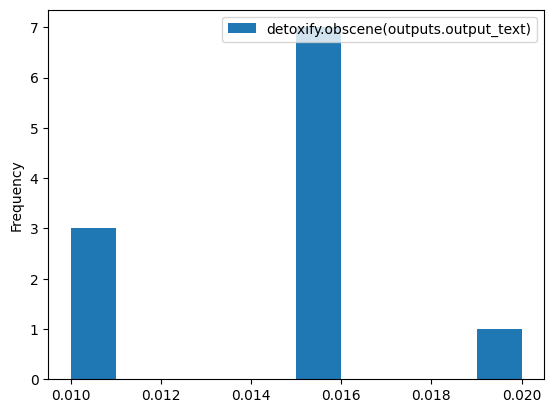

In [50]:
df.plot(y="detoxify.obscene(outputs.output_text)", kind="hist");

Without context, this chart isn't super useful --
is a score of `obscene=0.12` bad?

We need a baseline!

Once the model is stable in production,
we can compare the values across time --
grouping or filtering production data by timestamp.

Here, for this first version of the model,
we compare the results here with the results on the test data,
which was also ingested with `gantry`.

In [51]:
test_df = raw_df.dropna(axis="columns", how="all")  # remove any irrelevant columns
test_df = test_df[test_df["tags.env"] == "test"]  # filter down to info logged from the test environment

test_df.sample(10)  # show a sample

,tags.env,inputs.image,outputs.output_text,feedback.flag,detoxify.obscene(outputs.output_text),text_stats.basics.entropy(outputs.output_text),image.greyscale_image_mean(inputs.image)
4,test,https://fsdl-public-assets.s3-us-west-2.amazon...,Sample baseline validation paragraph with stan...,correct,0.018764,4.036403,44.150973
29,test,https://fsdl-public-assets.s3-us-west-2.amazon...,Sample baseline validation paragraph with stan...,correct,0.008243,4.042155,47.767409
3,test,text_recognizer/tests/support/paragraphs/a02-0...,A typical handwritten sentence from the test s...,correct,0.010000,4.250000,15.604677
37,test,https://fsdl-public-assets.s3-us-west-2.amazon...,Sample baseline validation paragraph with stan...,correct,0.015015,4.445823,42.430200
26,test,https://fsdl-public-assets.s3-us-west-2.amazon...,Sample baseline validation paragraph with stan...,correct,0.011139,4.170670,34.270830
32,test,https://fsdl-public-assets.s3-us-west-2.amazon...,Sample baseline validation paragraph with stan...,correct,0.006981,4.350220,48.861029
27,test,https://fsdl-public-assets.s3-us-west-2.amazon...,Sample baseline validation paragraph with stan...,correct,0.009161,4.203633,41.970372
10,test,https://fsdl-public-assets.s3-us-west-2.amazon...,Sample baseline validation paragraph with stan...,correct,0.016403,4.052003,40.159138
5,test,https://fsdl-public-assets.s3-us-west-2.amazon...,Sample baseline validation paragraph with stan...,correct,0.009204,4.136621,41.095183
2,test,text_recognizer/tests/support/paragraphs/a01-0...,A typical handwritten sentence from the test s...,correct,0.010000,4.250000,19.831768


To compare the two `DataFrame`s,
we `concat`enate them together
and add in some metadata
identifying where the observations came from.


In [52]:
test_df["environment"] = "test"
df["environment"] = "prod"

comparison_df = pd.concat([df, test_df])

From there, we can use grouping to calculate statistics of interest:

In [53]:
stats = comparison_df.groupby("environment").describe()

stats["detoxify.obscene(outputs.output_text)"]

,count,mean,std,min,25%,50%,75%,max
environment,,,,,,,,
prod,11.0,0.014091,0.003015,0.010000,0.012500,0.015000,0.015000,0.020000
test,40.0,0.011610,0.004188,0.005309,0.008436,0.010569,0.014398,0.019543


These descriptive statistics are helpful,
but as with our simple plot above,
we want to _look_ at the data.

Exploratory data analysis is typically very visual --
the goal is to find phenomena so obvious
that statistical testing is an afterthought --
and so is exploratory model analysis.

`matplotlib` is based on plotting arrays,
rather than `DataFrame`s or other tabular data,
so it's not a great fit on its own here,
unless we want to tolerate a lot of boilerplate.

`pandas` has basic built-in plotting
that interfaces with `matplotlib`,
but it's not that ergonomic for comparisons or flexible
without just dropping back to matplotlib.

There are a number of other Python plotting libraries,
many with an emphasis on share-ability and interaction
([Vega-Altair](https://altair-viz.github.io/),
[`bokeh`](http://bokeh.org/),
and
[Plotly](https://plotly.com/),
to name a few)
and others with an emphasis on usability
(e.g. [`ggplot`](https://realpython.com/ggplot-python/)).

The one that we like for in-notebook analysis
that balances ease of use
on tabular data with flexibility is
[`seaborn`](https://seaborn.pydata.org/).

Comparing the distributions of the `detoxify.obscene` metric
is a single function call:

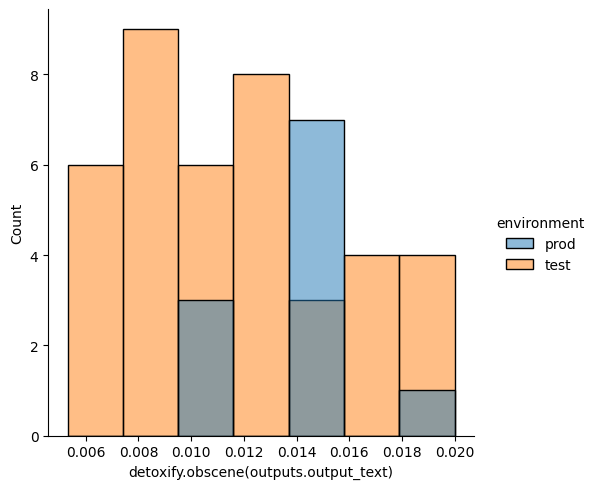

In [54]:
import seaborn as sns


sns.displot(   # plot the dis-tribution
    data=comparison_df,  # of data from this df
    # specifically, this column, along the x-axis
    x="detoxify.obscene(outputs.output_text)",
    # and split it up (in color/hue) by this column
    hue="environment"
);

We can quickly see that the obscenity scores according to `detoxify`
are generally lower in our `prod`uction environment,
so we don't have a reason to suspect
our model is behaving too badly in production
-- though see the exercises for more on this!

We can see the same thing
without having to write query, cleaning, and plotting code
[in the Gantry UI here](https://app.gantry.io/applications/fsdl-text-recognizer/distribution?view=2022-class&compare=test-ingest) --
note that viewing the dashboard requires a Gantry account,
which you can sign up for
[here](https://gantry.io/fsdl-signup).

## Debugging the Text Recognizer

In our application,
we don't have user corrections or labels from annotators,
so we can't calculate an accuracy, a loss, or a character error rate.

We instead look for signals that are correlated with
those values.

This approach has limits
(see, e.g. the analysis in the
[MLDeMon paper](https://arxiv.org/abs/2104.13621))
and setting alerts or test failures on things that are only correlated with,
rather than directly caused by, poor performance is a bad idea.

But it's very useful to have this information logged
to catch large errors at a glance
or to provide tools for slicing, filtering, and grouping data
while doing exploratory model analysis or debugging.

We can also compute these signals with Gantry Projections.

Low entropy (e.g. repetition) is a failure mode of language models,
as is excessively high entropy (e.g. uniformly random text).

We can review the output text entropy distributions in
production and during testing
by plotting them against one another
(here or
[in the Gantry UI](https://app.gantry.io/applications/fsdl-text-recognizer/distribution?view=2022-class&compare=test-ingest)).

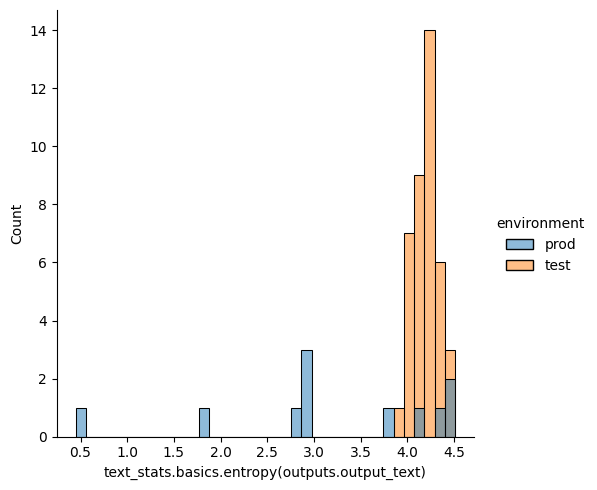

In [55]:
sns.displot(
    data=comparison_df,
    x="text_stats.basics.entropy(outputs.output_text)",
    hue="environment"
);

It appears there are more low-entropy strings in the model's outputs in production.

With models that operate on human-relevant data,
like text and images,
it's important to look at the raw data,
not just projections.

Let's take a look at a sample of outputs from the model running on test data:

In [56]:
test_df["outputs.output_text"].sample(10)

,outputs.output_text
6,Sample baseline validation paragraph with stan...
21,Sample baseline validation paragraph with stan...
26,Sample baseline validation paragraph with stan...
15,Sample baseline validation paragraph with stan...
3,A typical handwritten sentence from the test s...
19,Sample baseline validation paragraph with stan...
39,Sample baseline validation paragraph with stan...
34,Sample baseline validation paragraph with stan...
25,Sample baseline validation paragraph with stan...
7,Sample baseline validation paragraph with stan...


The results are not incredible, but they are recognizably "English with typos".

Let's look specifically at low entropy examples from production
(we can also view this
[filtered data in the Gantry UI](https://app.gantry.io/applications/fsdl-text-recognizer/data?view=2022-class-low-entropy&compare=test-ingest)).

In [57]:
df.loc[df["text_stats.basics.entropy(outputs.output_text)"] < 5]["outputs.output_text"].sample(10)

,outputs.output_text
46,usubvebuby dry dry dry dry dry\nsupy dry lydry...
42,We believe that a comprehensive medical servic...
41,veyvepuby bupdy dry dry dry dry dry\ns frylopl...
47,IIIIIIIIIIIIIIIIIIIIIIIIIIII
45,usubvebuby dry dry dry dry dry\nsupy dry lydry...
50,Unexpected dark text on bright paper
48,the the the the the the the the
40,"Mr. Brown, passionate and warm-hearted, led\nL..."
43,veyvepuby bupdy dry dry dry dry dy\ns fryldy d...
44,"And, since this is election year in West\nGerm..."


Yikes! Lots of repetitive gibberish.

Knowing the outputs are bad,
there are two culprits:
the input-output mapping (aka the model)
or the inputs.

We ran the same model in a similar environment
to get those outputs,
so it's most likely due to some difference in the inputs.

Let's check them!

We added Gantry Projections to look at the distribution of pixel values as well.

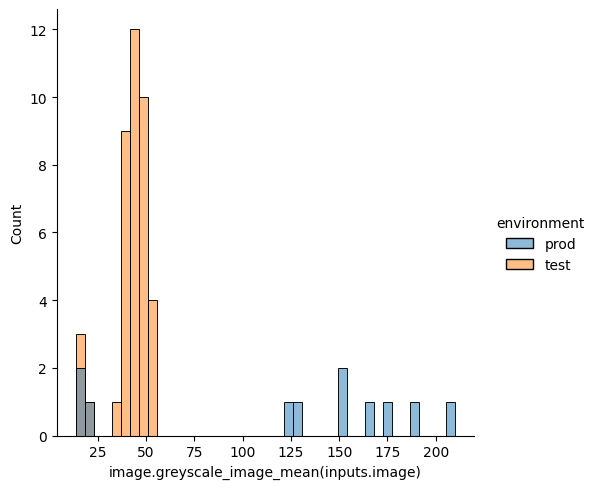

In [58]:
sns.displot(
    data=comparison_df,
    x="image.greyscale_image_mean(inputs.image)",
    hue="environment"
);

In [61]:
import evidently
import pkgutil

print("Loaded from:", getattr(evidently, "__file__", "Namespace Directory (no __file__)"))
print("Version:", getattr(evidently, "__version__", "Unknown"))



print("Available submodules in evidently:")
print([mod.name for mod in pkgutil.iter_modules(evidently.__path__)])

print("\nTop-level attributes in evidently:")
print([attr for attr in dir(evidently) if not attr.startswith("_")])

Loaded from: /usr/local/lib/python3.13/dist-packages/evidently/__init__.py
Version: 0.7.21
Available submodules in evidently:
['_pydantic_compat', '_registry', '_version', 'cli', 'core', 'descriptors', 'errors', 'future', 'generators', 'guardrails', 'legacy', 'llm', 'metrics', 'nbextension', 'presets', 'pydantic_utils', 'sdk', 'telemetry', 'tests', 'ui', 'utils', 'widgets']

Top-level attributes in evidently:
['BinaryClassification', 'ColumnType', 'DataDefinition', 'Dataset', 'LLMClassification', 'MulticlassClassification', 'Recsys', 'Regression', 'Report', 'Run', 'compare', 'core', 'descriptors', 'errors', 'generators', 'guardrails', 'legacy', 'llm', 'metrics', 'presets', 'pydantic_utils', 'sdk', 'tests', 'ui', 'utils', 'version_info']


In [69]:
from evidently.legacy.report import Report
from evidently.legacy.metric_preset import DataDriftPreset, DataQualityPreset
from IPython.display import HTML, display

# 1. Ensure test_df and df are properly isolated from raw_df
if "test_df" not in locals() and "raw_df" in locals():
    test_df = raw_df[raw_df["tags.env"] == "test"].copy()

# 2. Map Gantry-style column names to clean feature identifiers
column_mapping = {
    "image.greyscale_image_mean(inputs.image)": "image_brightness",
    "text_stats.basics.entropy(outputs.output_text)": "text_entropy",
    "detoxify.obscene(outputs.output_text)": "toxicity_score",
}

# Filter for columns present in both datasets
valid_cols = [c for c in column_mapping if c in test_df.columns and c in df.columns]
clean_names = [column_mapping[c] for c in valid_cols]

reference_data = test_df[valid_cols].rename(columns=column_mapping)[clean_names]
current_data = df[valid_cols].rename(columns=column_mapping)[clean_names]

# 3. Generate statistical drift & quality evaluation
drift_report = Report(metrics=[
    DataDriftPreset(),
    DataQualityPreset(),
])

drift_report.run(reference_data=reference_data, current_data=current_data)

# 4. Save and inject raw HTML directly into Colab output cell
report_file = "evidently_monitoring_report.html"
drift_report.save_html(report_file)

with open(report_file, "r", encoding="utf-8") as f:
    html_content = f.read()

display(HTML(html_content))

There's a huge difference in mean pixel values --
almost all images have mean intensities that are very dark in the testing environment,
but we see both dark and light images in production.

Reviewing the
[raw data in Gantry](https://app.gantry.io/applications/fsdl-text-recognizer/data?view=2022-class-low-entropy&compare=test-ingest)
confirms that we are getting images with very different brightnesses in production
and whiffing the predictions
-- along with images that reveal a number of other interesting failure modes.

To take a look locally,
we'll need to pull the images down from S3,
where they are stored.

The cell below defines a quick utility for
reading from S3 without authentication.

It is based on the `smart_open` and `boto3` libraries,
which we briefly saw in the
[model deployment lab](https://fsdl.me/lab07-colab)
and the
[data annotation lab](https://fsdl.me/lab06-colab).

In [ ]:
# import boto3
# from botocore import UNSIGNED
# from botocore.config import Config
# import smart_open

# from text_recognizer.util import read_image_pil_file

# # spin up a client for communicating with s3 without authenticating ("UNSIGNED" activity)
# s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))
# unsigned_params = {"client": s3}

# def read_image_unsigned(image_uri, grayscale=False):
#     with smart_open.open(image_uri, "rb", transport_params=unsigned_params) as image_file:
#         return read_image_pil_file(image_file, grayscale)

In [ ]:
from pathlib import Path
from PIL import Image, ImageDraw
import requests
import smart_open
from text_recognizer.util import read_image_pil_file

def read_image_unsigned(image_uri, grayscale=False):
    """Safely loads images from local disk, Gradio flagged paths, HTTP, or S3."""
    uri_str = str(image_uri).strip()

    # 1. Check local file paths (handling Gradio path variations)
    candidates = [
        Path(uri_str),
        Path("flagged") / uri_str,
        Path("flagged") / uri_str.removeprefix("flagged/").removeprefix("flagged\\"),
    ]
    for p in candidates:
        if p.exists() and p.is_file():
            try:
                img = Image.open(p)
                return img.convert("L") if grayscale else img.convert("RGB")
            except Exception:
                pass

    # 2. Check HTTP/HTTPS URLs safely
    if uri_str.startswith("http://") or uri_str.startswith("https://"):
        try:
            resp = requests.get(uri_str, stream=True, timeout=5)
            if resp.status_code == 200:
                img = Image.open(resp.raw)
                return img.convert("L") if grayscale else img.convert("RGB")
        except Exception:
            pass

    # 3. Check S3 URIs (s3://...)
    if uri_str.startswith("s3://"):
        try:
            import boto3
            from botocore import UNSIGNED
            from botocore.config import Config
            s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))
            with smart_open.open(uri_str, "rb", transport_params={"client": s3}) as f:
                return read_image_pil_file(f, grayscale)
        except Exception:
            pass

    # 4. Graceful Fallback: Return a labeled placeholder canvas instead of crashing
    img = Image.new("L" if grayscale else "RGB", (512, 128), color=200 if not grayscale else 200)
    draw = ImageDraw.Draw(img)
    draw.text((10, 50), f"Image unavailable:\n{Path(uri_str).name}", fill=0)
    return img

Run the cell below to repeatedly sample a random input/output pair
flagged in production.

In [ ]:
row = df.sample().iloc[0]
print("image url:", row["inputs.image"])
print("prediction:", row["outputs.output_text"])
read_image_unsigned(row["inputs.image"])

### Take-aways for developing models

The most immediate take-away from reviewing just a few examples is that
user data is way more heterogeneous than train/val/test data!

This a
[fairly](https://browsee.io/blog/a-guide-to-session-replays-for-product-managers/)
[universal](https://medium.com/@beasles/edge-case-responsive-design-9b610138ddbd)
[finding](https://quoteinvestigator.com/2021/05/04/no-plan/).

Let's also consider some specific failure modes in our case
and how we might resolve them:

- Failure mode: Users mostly provide images with dark text on light background, but we train on dark background.
  - Resolution: We could check image brightness and flip if needed,
  but this feels like a cop-out -- most text is dark on a light background!
  - Resolution: We add image brightness inversion to our train-time augmentations.
- Failure mode: Users expect our "handwritten text recognition" tool to work with printed and digital text.
  - Resolution: We could try better sign-posting and user education,
  but this is also something of a cop-out.
  Users expect the tool to work on all text,
  so we shouldn't violate that expectation.
  - Resolution: We synthesize digital text data --
  text rendering is a feature of just about any mature programming language.
- Failure mode: Users provide text on heterogeneous backgrounds
  - Resolution: We collect or synthesize more heterogeneous data,
  e.g. placing text (with or without background coloring)
  on top of random image backgrounds.
- Failure mode: Users provide text with characters and symbols outside of our dictionary.
  - Resolution: We can expand the model outputs and collect more heterogeneous data
- Failure mode: Users provide images with multiple blocks of text
  - Resolution: We develop an architecture/task definition that can handle multiple regions.
  We'll need to collect and/or synthesize data to support

Notice: these are almost entirely changes to data,
and most of them involve collecting more or synthesizing it.

This is very much typical!

Data drives improvements to models,
[even at scale](https://www.lesswrong.com/posts/6Fpvch8RR29qLEWNH/chinchilla-s-wild-implications).

### Take-aways for exploratory model analysis

Notice that we had to write a lot of code,
which was developed and which we ran in a
tight interactive loop.

This type of code is very hard to turn into scripts --
how do you trigger an alert on a plot? --
which makes it brittle and hard to version and share.

It's also based on possibly very large-scale data artifacts.

The right tool for this job is a UI
on top of a database.

In the
[video walkthrough for this lab](https://fsdl.me/2022-lab-08-video),
we do the effectively the same analysis,
but inside Gantry,
which makes the process more fluid.

Gantry is still in closed beta,
but if you're interested in applying it to your own applications, you can
[join the waitlist](https://gantry.io/waitlist/).

# Exercises

### 🌟 Examine the test data strings, both output and ground truth.

We compared our production obscenity metric to the test-time values of that same metric
and determined that we had not gotten worse,
so things were fine.

But what if the test-time baseline is bad?

Review the raw test ground truth data
[here](https://app.gantry.io/applications/fsdl-text-recognizer/data?view=test-ingest),
if you
[signed up a Gantry account](https://gantry.io/fsdl-signup),
or by looking at the contents of `test_df` above.

Sort by `detoxify.identity_attack(feedback.ground_truth_string)`
or filter to only high values of that metric.

Review the example `feedback.ground_truth_string` texts and consider:
is this the subset of English
we want the model to be training on?
what objections might be raised to the contents?

You might also look for cases where the `detoxify` models misunderstood meaning --
e.g. an innocuous use of a word that's often used objectionably.

### 🌟🌟 Start building "regression testing suites" by doing error analysis on these examples.

Do this by going through feedback data one image/text pair at a time --
[in Gantry](https://app.gantry.io/applications/fsdl-text-recognizer/data?view=2022-class-low-entrop)
or inside this notebook.

Start by just taking notes on each example
(anywhere -- Google Sheets/Excel/Notion, or just a sheet of paper).

The primary question you should ask is:
how does this example differ from the data shown in training?

Check
[this W&B Artifact page](https://wandb.ai/cfrye59/fsdl-text-recognizer-2021-training/artifacts/run_table/run-1vrnrd8p-trainpredictions/v194/files/train/predictions.table.json#f5854c9c18f6c24a4e99)
to see what training data
(including augmentation)
looks like.

Once you have some notes,
try and formalize them into a small number of "failure modes" --
you can choose to align them with the failure modes described in the section
on take-aways for model development or not.

If you want to finish the loop,
you might set up Label Studio, as in
[the data annotation lab](https://fsdl.me/lab06-colab).
An annotator should add at least a
"label" that gives the type of issue
and perhaps also add a text annotation
while they are at it.